# Electrical Systems Modeling, Simulation and Control

Includes RC, RL, series/parallel RLC concepts, classical/state-space/digital control, DC motor, transformer, three-phase power, generator swing equation, simplified induction-motor torque-slip behavior, buck/boost converters, PWM inverter concept, PID, observer, LQR/Kalman and robustness.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.linalg as la
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

try:
    import control as ct
    HAS_CONTROL = True
except Exception as e:
    HAS_CONTROL = False
    print("Install python-control with: pip install control")
    print(e)

In [2]:
def stability_from_poles(poles, tol=1e-8):
    p=np.asarray(poles,dtype=complex)
    if np.any(np.real(p)>tol): return "UNSTABLE"
    if np.all(np.real(p)<-tol): return "ASYMPTOTICALLY STABLE"
    return "MARGINALLY STABLE"

def damping_label(zeta,tol=.02):
    if zeta < 0: return "UNSTABLE / NEGATIVE DAMPING"
    if abs(zeta)<1e-8: return "UNDAMPED"
    if zeta < 1-tol: return "UNDERDAMPED"
    if zeta <= 1+tol: return "CRITICALLY DAMPED (approximately)"
    return "OVERDAMPED"

def modal_label(poles):
    p=np.asarray(poles,dtype=complex)
    st=stability_from_poles(p)
    cp=[z for z in p if abs(np.imag(z))>1e-8]
    if cp:
        d=max(cp,key=lambda z:np.real(z))
        zeta=-np.real(d)/abs(d)
        if st=="UNSTABLE": return "OSCILLATORY UNSTABLE",st,zeta
        if zeta<.98: return "UNDERDAMPED",st,zeta
        if zeta<=1.02: return "CRITICALLY DAMPED-LIKE",st,zeta
        return "OVERDAMPED-LIKE",st,zeta
    return ("OVERDAMPED-LIKE / NON-OSCILLATORY" if st=="ASYMPTOTICALLY STABLE" else st),st,None

def metrics(t,y,final=None):
    t=np.asarray(t); y=np.asarray(y)
    if final is None: final=y[-1]
    peak_i=int(np.argmax(y)); peak=y[peak_i]
    overshoot=np.nan if abs(final)<1e-12 else max(0,(peak-final)/abs(final)*100)
    def cross(level):
        idx=np.where(y>=level)[0] if final>=0 else np.where(y<=level)[0]
        return t[idx[0]] if len(idx) else np.nan
    t10,t90=cross(.1*final),cross(.9*final)
    rise=t90-t10 if np.isfinite(t10) and np.isfinite(t90) else np.nan
    band=.02*max(abs(final),1e-12)
    out=np.where(np.abs(y-final)>band)[0]
    settle=0 if len(out)==0 else (t[out[-1]+1] if out[-1]<len(t)-1 else np.nan)
    return dict(rise_time=rise,settling_time=settle,peak_time=t[peak_i],overshoot_percent=overshoot,peak_value=peak)

def routh_table(coeffs):
    a=np.asarray(coeffs,float)
    n=len(a)-1; c=int(np.ceil((n+1)/2))
    R=np.zeros((n+1,c))
    R[0,:len(a[0::2])]=a[0::2]
    R[1,:len(a[1::2])]=a[1::2]
    eps=1e-9
    for i in range(2,n+1):
        if abs(R[i-1,0])<eps: R[i-1,0]=eps
        for j in range(c-1):
            R[i,j]=(R[i-1,0]*R[i-2,j+1]-R[i-2,0]*R[i-1,j+1])/R[i-1,0]
    s=np.sign(R[:,0]); changes=int(np.sum(s[:-1]*s[1:]<0))
    return R,changes

def jury_second_order(a):
    a0,a1,a2=map(float,a)
    cond={"|a2|<a0":abs(a2)<a0,"P(1)>0":a0+a1+a2>0,"P(-1)>0":a0-a1+a2>0}
    return cond,all(cond.values())

## Interactive RLC damping/stability

In [3]:
def rlc(R=10,L=.5,C=.01,Vs=24):
    wn=1/np.sqrt(L*C); z=(R/2)*np.sqrt(C/L); p=np.linalg.eigvals([[0,1],[-1/(L*C),-R/L]])
    print("Response:",damping_label(z)); print("Stability:",stability_from_poles(p)); print("Poles:",p); print("Critical R:",2*np.sqrt(L/C))
    def f(t,y): q,i=y; return [i,(Vs-R*i-q/C)/L]
    t=np.linspace(0,2,1800); sol=solve_ivp(f,[0,2],[0,0],t_eval=t); vc=sol.y[0]/C
    print(metrics(t,vc,Vs)); plt.figure(figsize=(9,4)); plt.plot(t,vc); plt.axhline(Vs,ls="--"); plt.grid(True); plt.show()
widgets.interact(rlc,R=(-10.,100.,.5),L=(.01,5.,.05),C=widgets.FloatLogSlider(value=.01,base=10,min=-4,max=-1,step=.1),Vs=(1.,240.,1.));

interactive(children=(FloatSlider(value=10.0, description='R', min=-10.0, step=0.5), FloatSlider(value=0.5, de…

## Classical control analysis

Poles: [-10.+10.j -10.-10.j]
Zeros: []


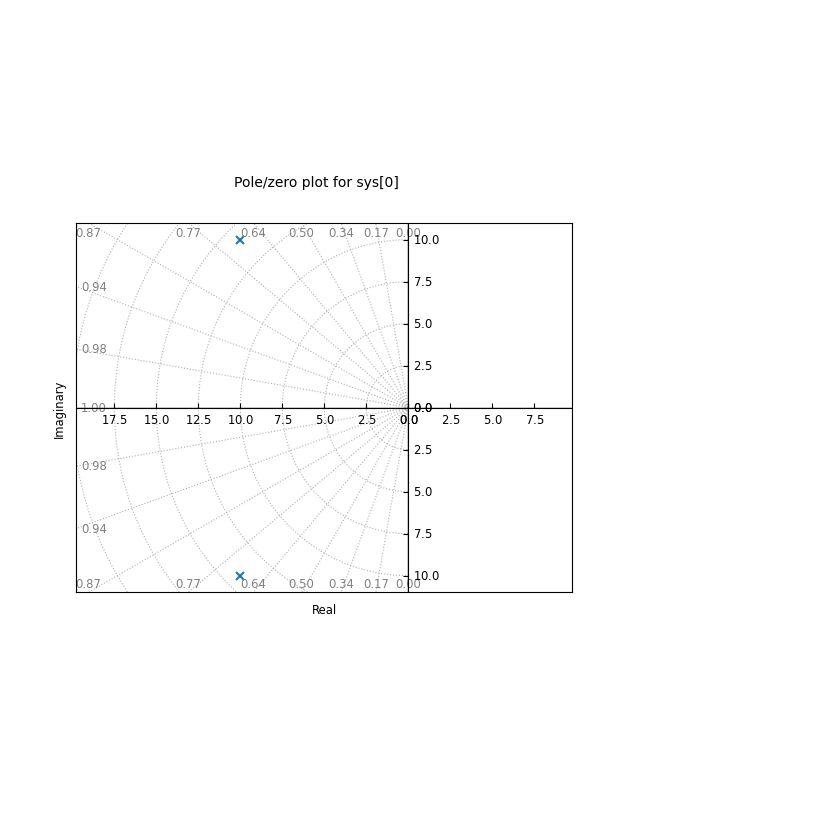

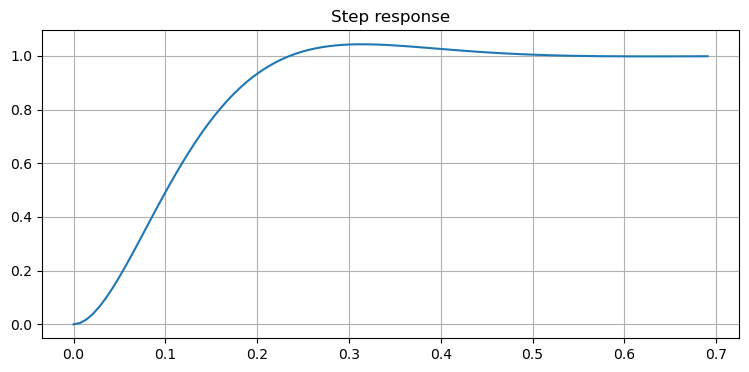

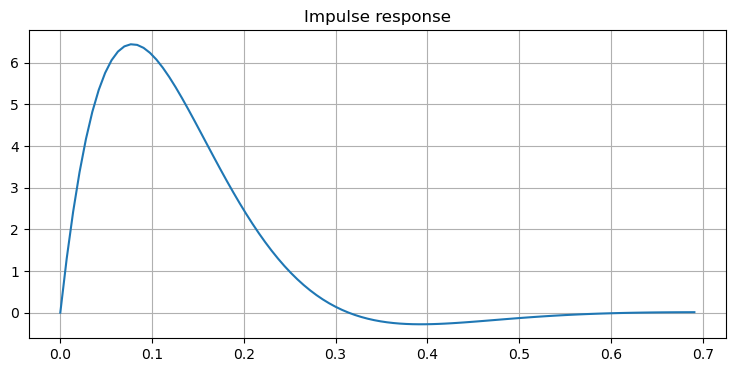

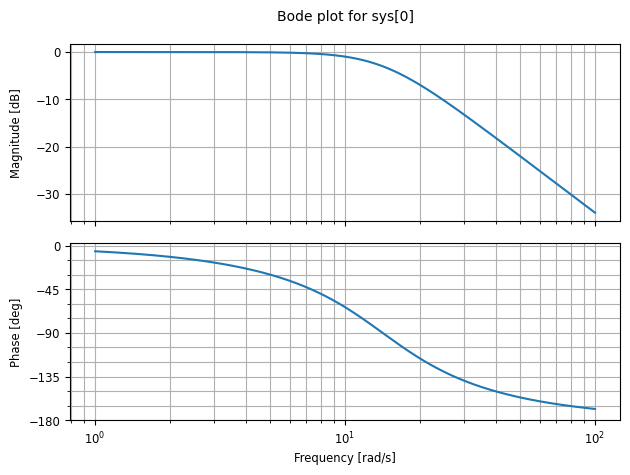

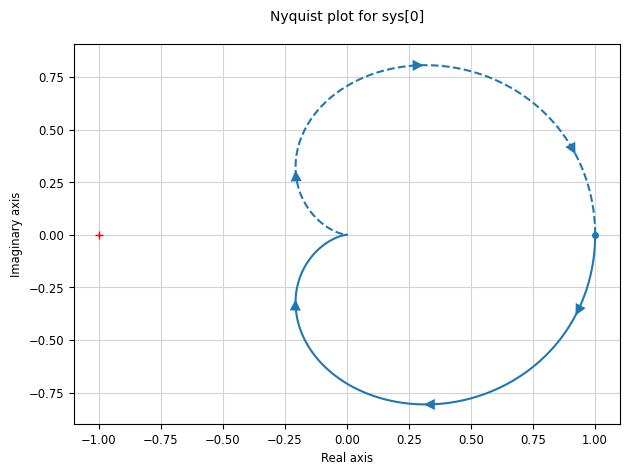

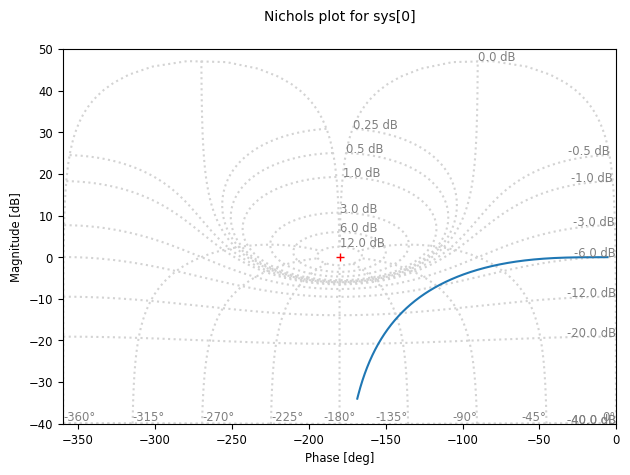

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


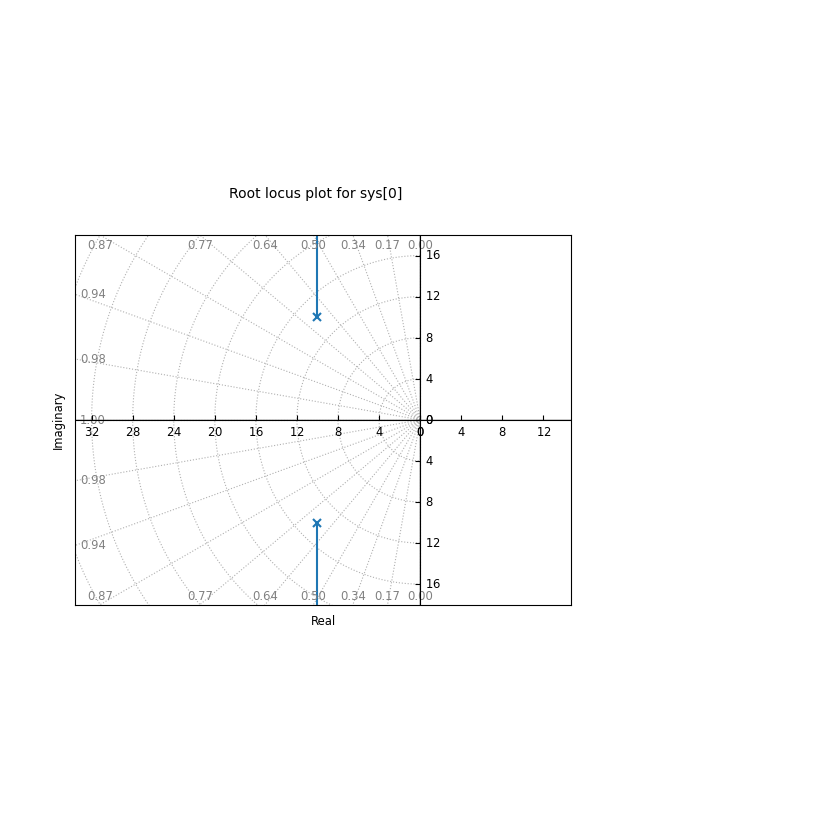

Margins (GM, PM, Wcg, Wcp): (inf, inf, nan, nan)
Bandwidth: 14.125355536132572


In [4]:
G=ct.tf([1],[.005,.1,1])

if HAS_CONTROL:
    print("Poles:",ct.poles(G))
    print("Zeros:",ct.zeros(G))
    ct.pzmap(G,grid=True); plt.show()
    t,y=ct.step_response(G); plt.figure(figsize=(9,4)); plt.plot(t,y); plt.grid(True); plt.title("Step response"); plt.show()
    t,y=ct.impulse_response(G); plt.figure(figsize=(9,4)); plt.plot(t,y); plt.grid(True); plt.title("Impulse response"); plt.show()
    ct.bode_plot(G,dB=True,grid=True); plt.show()
    ct.nyquist_plot(G); plt.grid(True); plt.show()
    try:
        ct.nichols_plot(G,grid=True); plt.show()
    except Exception as e:
        print("Nichols:",e)
    ct.root_locus_plot(G,grid=True); plt.show()
    print("Margins (GM, PM, Wcg, Wcp):",ct.margin(G))
    try: print("Bandwidth:",ct.bandwidth(G))
    except Exception as e: print("Bandwidth:",e)

## Routh–Hurwitz, controllers, sensitivity and robustness

[[0.005 1.   ]
 [0.1   0.   ]
 [1.    0.   ]]
RHP roots: 0


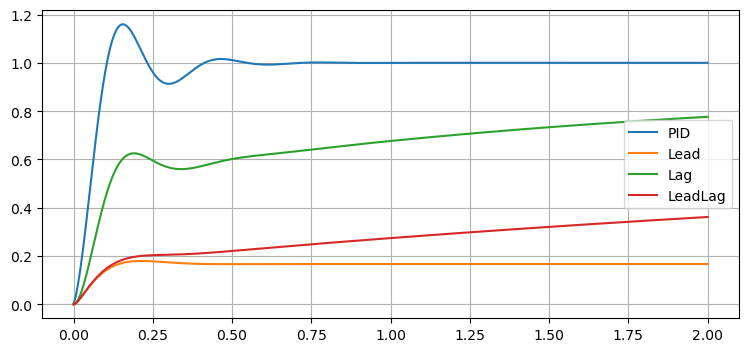

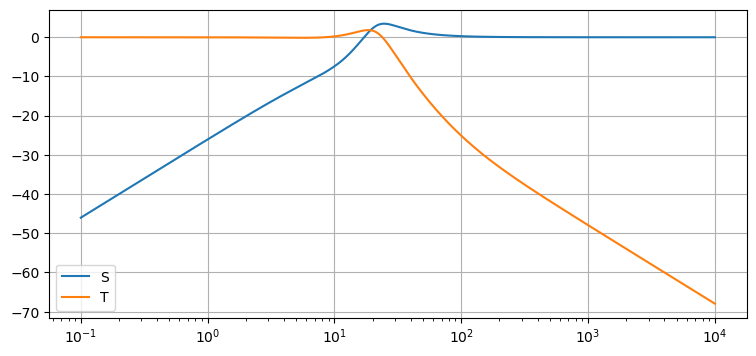

In [5]:
Rtab,chg=routh_table([.005,.1,1]); print(Rtab); print("RHP roots:",chg)
if HAS_CONTROL:
    G=ct.tf([1],[.005,.1,1]); PID=ct.tf([.02,2,20],[1,0]); lead=ct.tf([1,20],[1,100]); lag=ct.tf([1,1],[1,.1])
    t=np.linspace(0,2,1600); plt.figure(figsize=(9,4))
    for n,T in {"PID":ct.feedback(PID*G,1),"Lead":ct.feedback(lead*G,1),"Lag":ct.feedback(lag*G,1),"LeadLag":ct.feedback(lead*lag*G,1)}.items():
        tt,y=ct.step_response(T,T=t); plt.plot(tt,y,label=n)
    plt.grid(True); plt.legend(); plt.show()
    L=PID*G; S=1/(1+L); T=L/(1+L); w=np.logspace(-1,4,1000)
    Sr=ct.frequency_response(S,w).frdata.squeeze(); Tr=ct.frequency_response(T,w).frdata.squeeze()
    plt.figure(figsize=(9,4)); plt.semilogx(w,20*np.log10(abs(Sr)),label="S"); plt.semilogx(w,20*np.log10(abs(Tr)),label="T"); plt.grid(True); plt.legend(); plt.show()

## DC motor: electrical + mechanical domains

In [6]:
R,L,Ke,Kt,J,Bm=2,.5,.1,.1,.02,.02
A=np.array([[-R/L,-Ke/L],[Kt/J,-Bm/J]]); B=np.array([[1/L],[0]]); C=np.array([[0,1]])
print("Motor poles:",np.linalg.eigvals(A))
if HAS_CONTROL:
    Gm=ct.ss2tf(ct.ss(A,B,C,0)); print(Gm)
    print("Ctrb rank:",np.linalg.matrix_rank(ct.ctrb(A,B))); print("Obsv rank:",np.linalg.matrix_rank(ct.obsv(A,C)))
    Ksf=ct.place(A,B,[-5,-8]); Lobs=ct.place(A.T,C.T,[-15,-20]).T
    print("K:",Ksf); print("L:",Lobs)
    Klqr,S,E=ct.lqr(A,B,np.diag([1,50]),np.array([[1]])); print("LQR:",Klqr,E)
    try: print("Kalman:",ct.lqe(A,np.eye(2),C,np.diag([.05,.05]),np.array([[.01]])))
    except Exception as e: print(e)

Motor poles: [-3.61803399 -1.38196601]
<TransferFunction>: sys[44]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  8.882e-16 s + 10
  ----------------
   s^2 + 5 s + 5
Ctrb rank: 2
Obsv rank: 2
K: [[4.  2.7]]
L: [[35.]
 [30.]]
LQR: [[3.84095587 5.82335309]] [-6.34095587+5.5414548j -6.34095587-5.5414548j]
Kalman: (array([[0.35757434],
       [2.0944698 ]]), array([[0.00591139, 0.00357574],
       [0.00357574, 0.0209447 ]]), array([-3.5472349+1.60713268j, -3.5472349-1.60713268j]))


## RC, RL and parallel RLC examples

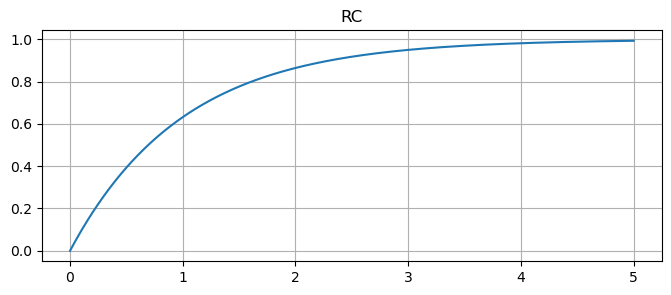

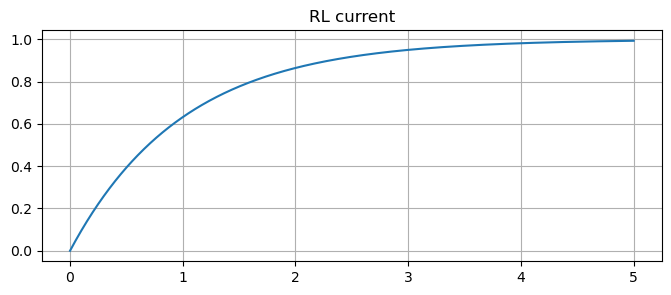

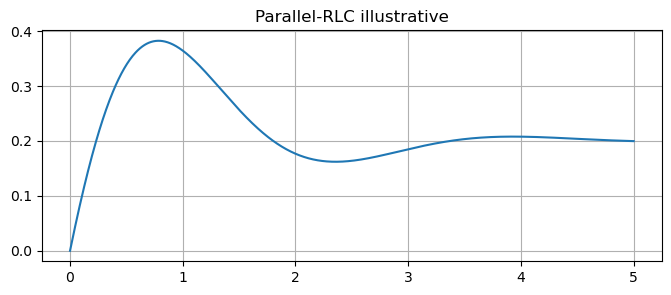

In [7]:
if HAS_CONTROL:
    examples={"RC":ct.tf([1],[1,1]),"RL current":ct.tf([1],[1,1]),"Parallel-RLC illustrative":ct.tf([1,1],[1,2,5])}
    for n,Gx in examples.items():
        t,y=ct.step_response(Gx,T=np.linspace(0,5,1000)); plt.figure(figsize=(8,3)); plt.plot(t,y); plt.grid(True); plt.title(n); plt.show()

## Buck and boost converters

In [8]:
def buck(Vin=24,D=.5,Lc=1e-3,Cc=470e-6,Rload=10):
    def f(t,y): i,v=y; return [(D*Vin-v)/Lc,(i-v/Rload)/Cc]
    t=np.linspace(0,.03,1800); sol=solve_ivp(f,[0,.03],[0,0],t_eval=t)
    plt.figure(figsize=(9,3)); plt.plot(t,sol.y[1]); plt.grid(True); plt.show(); print("Ideal Vout:",D*Vin)
widgets.interact(buck,Vin=(5.,60.,1.),D=(.05,.95,.05),Rload=(1.,50.,1.));

def boost(Vin=12,D=.5,Lc=1e-3,Cc=470e-6,Rload=20):
    def f(t,y): i,v=y; return [(Vin-(1-D)*v)/Lc,((1-D)*i-v/Rload)/Cc]
    t=np.linspace(0,.03,1800); sol=solve_ivp(f,[0,.03],[0,0],t_eval=t)
    plt.figure(figsize=(9,3)); plt.plot(t,sol.y[1]); plt.grid(True); plt.show(); print("Ideal Vout:",Vin/(1-D))
widgets.interact(boost,Vin=(5.,30.,1.),D=(.05,.9,.05),Rload=(2.,100.,2.));

interactive(children=(FloatSlider(value=24.0, description='Vin', max=60.0, min=5.0, step=1.0), FloatSlider(val…

interactive(children=(FloatSlider(value=12.0, description='Vin', max=30.0, min=5.0, step=1.0), FloatSlider(val…

## Transformer and three-phase power

In [9]:
def xfmr(V1=11000,N1=1000,N2=100,I2=100,pf=.9):
    V2=V1*N2/N1; I1=I2*N2/N1; S=np.sqrt(3)*V1*I1; P=S*pf
    print("V2:",V2,"V  I1:",I1,"A  S:",S/1e6,"MVA  P:",P/1e6,"MW")
widgets.interact(xfmr,V1=(400.,33000.,100.),N1=(100,5000,100),N2=(10,1000,10),I2=(1.,1000.,10.),pf=(.1,1.,.05));

interactive(children=(FloatSlider(value=11000.0, description='V1', max=33000.0, min=400.0, step=100.0), IntSli…

## Generator swing equation

In [ ]:
def swing(H=5,D=1,Pm=1,Pe=.8):
    def f(t,y): d,w=y; return [w,(Pm-Pe-D*w)/(2*H)]
    t=np.linspace(0,10,1400); sol=solve_ivp(f,[0,10],[0,0],t_eval=t)
    plt.figure(figsize=(9,3)); plt.plot(t,sol.y[1]); plt.grid(True); plt.title("Rotor-speed deviation"); plt.show()
widgets.interact(swing,H=(.5,10.,.5),D=(0.,5.,.2),Pm=(0.,2.,.1),Pe=(0.,2.,.1));

interactive(children=(FloatSlider(value=5.0, description='H', max=10.0, min=0.5, step=0.5), FloatSlider(value=…

## Simplified induction motor torque-slip curve

In [11]:
def induction(R2=.4,Xeq=1.5,Vth=230):
    s=np.linspace(.01,1,900); tq=(Vth**2*(R2/s))/((R2/s)**2+Xeq**2)
    plt.figure(figsize=(9,3)); plt.plot(s,tq); plt.grid(True); plt.xlabel("Slip"); plt.ylabel("Relative torque"); plt.show()
widgets.interact(induction,R2=(.05,2.,.05),Xeq=(.1,5.,.1),Vth=(50.,500.,10.));

interactive(children=(FloatSlider(value=0.4, description='R2', max=2.0, min=0.05, step=0.05), FloatSlider(valu…

## SPWM inverter concept

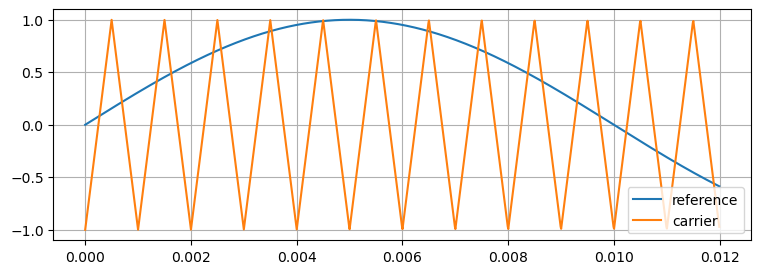

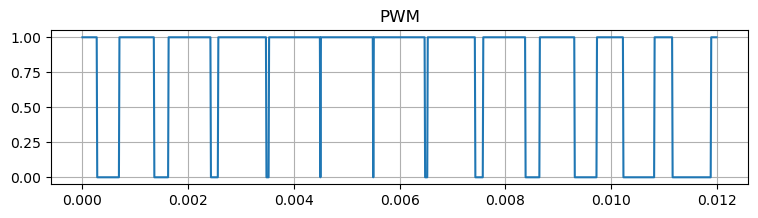

In [12]:
fs=50; fc=1000; t=np.linspace(0,.04,4000)
ref=np.sin(2*np.pi*fs*t); carrier=signal.sawtooth(2*np.pi*fc*t,.5); pwm=(ref>carrier).astype(float)
plt.figure(figsize=(9,3)); plt.plot(t[:1200],ref[:1200],label="reference"); plt.plot(t[:1200],carrier[:1200],label="carrier"); plt.grid(True); plt.legend(); plt.show()
plt.figure(figsize=(9,2)); plt.plot(t[:1200],pwm[:1200]); plt.grid(True); plt.title("PWM"); plt.show()

## Digital RLC and Jury stability

In [13]:
if HAS_CONTROL:
    G=ct.tf([1],[.005,.1,1]); Gd=ct.sample_system(G,.001,'zoh'); print(Gd)
    p=ct.poles(Gd); print("Discrete poles:",p); print("Stable?",np.all(abs(p)<1))
    den=np.squeeze(Gd.den)
    if len(den)==3: print(jury_second_order(den))

<TransferFunction>: sys[51]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.001

  9.933e-05 z + 9.867e-05
  -----------------------
   z^2 - 1.98 z + 0.9802
Discrete poles: [0.99000033+0.00990033j 0.99000033-0.00990033j]
Stable? True
({'|a2|<a0': True, 'P(1)>0': True, 'P(-1)>0': True}, True)


## Robust RLC parameter sweep

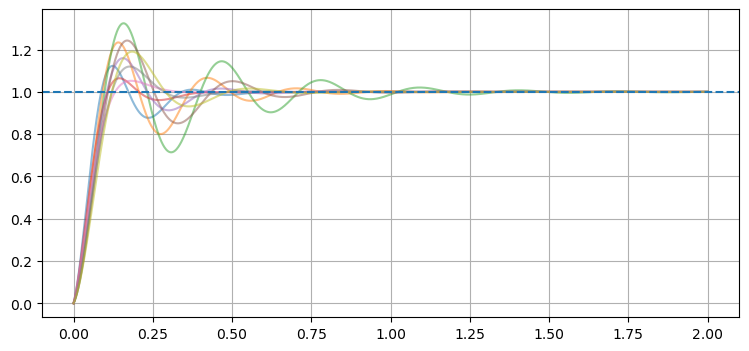

In [14]:
if HAS_CONTROL:
    Cc=ct.tf([.02,2,20],[1,0]); t=np.linspace(0,2,1200); plt.figure(figsize=(9,4))
    for R in [7,10,13]:
        for L in [.35,.5,.65]:
            T=ct.feedback(Cc*ct.tf([1],[L*.01,R*.01,1]),1); tt,y=ct.step_response(T,T=t); plt.plot(tt,y,alpha=.5)
    plt.axhline(1,ls="--"); plt.grid(True); plt.show()